In [31]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize,poly)
import matplotlib.pyplot as plt
from statsmodels.stats.anova import anova_lm
import math

np.random.seed(42)

X = np.random.normal(loc=0, scale=1, size=100)
eps = np.random.normal(loc=0, scale=0.25, size=100)
y = -1 + 0.5* X + eps

Длина вектора У - 100
В0 = -1
В1 = 0.5

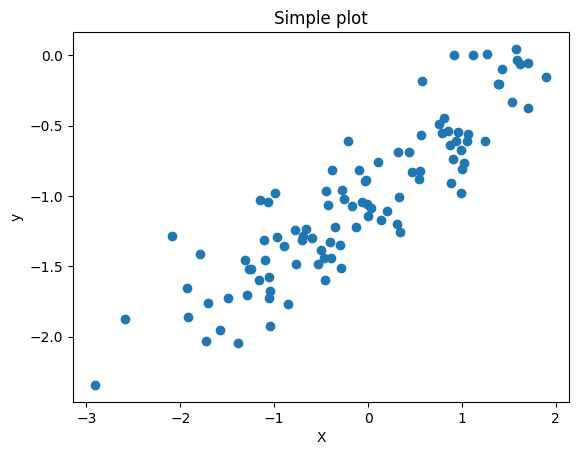

In [32]:
fig, ax = plt.subplots()
ax.scatter(X, y)
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Simple plot');

На графике заметна четка линейная зависимость между Х и У, причем даже по грпфику можно увидеть, что значение свободного члена около единицы.
Данные же распределены равномерно, что не удивительно ведь мы использовали распределение по Гаусу.

In [33]:
X_data = pd.DataFrame({'Intercept': 1, 'X': X})
results = sm.OLS(y,X_data).fit()
summarize(results)

,coef,std err,t,P>|t|
Intercept,-0.9821,0.025,-39.496,0.0
X,0.4565,0.023,19.619,0.0


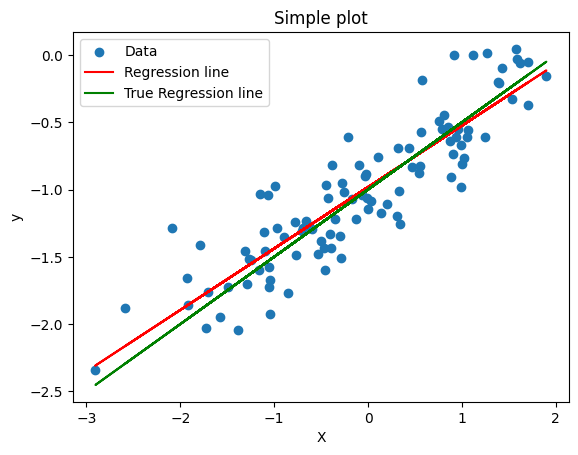

In [38]:
intercept = results.params.Intercept   
X_param = results.params.X

xlim = ax.get_xlim()
ylim = [X_param * xlim[0] + intercept, X_param * xlim[1] + intercept]

ax.plot(xlim, ylim, 'r--', linewidth=3);
plt.show()

fig, ax = plt.subplots()
ax.scatter(X, y, label="Data")
ax.plot(X, intercept + X_param * X, color='red', label="Regression line")
ax.plot(X, -1 + 0.5 * X, color='green', label="True Regression line")
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Simple plot')
ax.legend()
plt.show()

In [41]:
X_data_poly = pd.DataFrame({'Intercept': 1, 'X': X, 'X_poly': X ** 2})
results1 = sm.OLS(y,X_data_poly).fit()
summarize(results1)

,coef,std err,t,P>|t|
Intercept,-1.0260,0.032,-32.243,0.000
X,0.4723,0.024,19.684,0.000
X_poly,0.0400,0.019,2.154,0.034


In [42]:
anova_lm(results, results1)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,98.0,5.994312,0.0,NaN,NaN,NaN
1,97.0,5.720626,1.0,0.273686,4.640662,0.0337


Полиномиальная модель действительно прибавила немного в качестве, хотя и незначительно, тут конечно интересный момент, как
это скажется не предсказании результатов не на тестовом датасете, поскольку в реальности модель у нас линейная, а полиномиальность
привносит в нее некого рода нелинейность, что потенциально может снизить качество на контрольных данных

In [55]:
np.random.seed(42)
X1 = np.random.normal(loc=0,scale=0.5,size=100)
eps1 = np.random.normal(loc=0,scale=0.1,size=100)

y1 = -1 + 0.5 * X1 + eps1

X_data1 = pd.DataFrame({'Intercept': 1, 'X': X1})
results2 = sm.OLS(y1,X_data1).fit()
print('MSE1', results2.mse_total)
summarize(results2)

MSE1 0.05473525368055063


,coef,std err,t,P>|t|
Intercept,-0.9993,0.010,-104.545,0.0
X,0.4713,0.021,22.427,0.0


In [56]:
np.random.seed(42)
X2 = np.random.normal(loc=0,scale=1.5,size=100)
eps2 = np.random.normal(loc=0,scale=0.4,size=100)

y2 = -1 + 0.5 * X2 + eps2

X_data2 = pd.DataFrame({'Intercept': 1, 'X': X2})
results3 = sm.OLS(y2,X_data2).fit()
print('MSE2', results3.mse_total)
summarize(results3)

MSE2 0.5385580689933827


,coef,std err,t,P>|t|
Intercept,-0.9970,0.038,-26.078,0.0
X,0.4618,0.028,16.480,0.0


YНе сложно заметить, что если в данных меньше шума, то коэффициенты бета найдееные по МНК более близки к реальным,
чем в модели, обученной на данных с большим уровнем шума, хотя тут тоже все явно относительно,\
разница в коэффициентах между моделями не такая уж и большая, как и разница между коэффициентами, в теории чем больше
будет выборка для обучения тем по идее меньше должно быть влияние шума.

In [64]:
predictions = results.get_prediction(X_data)
summary_frame = predictions.summary_frame(alpha=0.05) 
y_pred = summary_frame['mean']
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

0    -1.631525
1    -0.374753
2    -1.488326
3    -0.823184
4    -1.077109
        ...   
95   -1.523849
96   -0.483585
97   -1.160517
98   -0.883805
99   -0.837751
Name: mean_ci_lower, Length: 100, dtype: float64